# EDA Assignment

**Name:** Rajat  
**Email:** rajatkangwal@gamail.com  
**Assignment:** EDA

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

def load_uploaded_file():
    # Works in Google Colab. If running locally, upload the file to the notebook
    # environment and change the filename in the small block below if needed.
    try:
        from google.colab import files
        uploaded = files.upload()
        if not uploaded:
            raise ValueError("No file was uploaded.")
        filename = next(iter(uploaded))
    except ImportError:
        filename = input("Enter CSV/XLSX filename: ").strip()

    if filename.lower().endswith(('.xlsx', '.xls')):
        df = pd.read_excel(filename)
    else:
        # utf-8 first, then a common fallback for CSV files
        try:
            df = pd.read_csv(filename)
        except UnicodeDecodeError:
            df = pd.read_csv(filename, encoding='latin1')

    df.columns = df.columns.astype(str).str.strip()
    return df

def scan_data(df, name):
    print(f"\n{name} dataset scanned successfully")
    print("Shape:", df.shape)
    display(df.head())
    print("\nColumn names:")
    print(df.columns.tolist())
    print("\nData types:")
    print(df.dtypes)
    print("\nMissing values:")
    print(df.isnull().sum())
    print("\nDuplicate rows:", df.duplicated().sum())

print("Libraries imported successfully")


# EDA - 1

## Bike Details Dataset

The assignment describes a used-bike dataset with 1061 records and 7 features: `name`, `selling_price`, `year`, `seller_type`, `owner`, `km_driven` and `ex_showroom_price`.

In [42]:
bike = load_uploaded_file()
scan_data(bike, "Bike Details")


Saving BIKE DETAILS.csv to BIKE DETAILS (2).csv

Bike Details dataset scanned successfully
Shape: (1061, 7)


,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN



Column names:
['name', 'selling_price', 'year', 'seller_type', 'owner', 'km_driven', 'ex_showroom_price']

Data types:
name                  object
selling_price          int64
year                   int64
seller_type           object
owner                 object
km_driven              int64
ex_showroom_price    float64
dtype: object

Missing values:
name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64

Duplicate rows: 6


## 1. What is the range of selling prices in the dataset?

In [43]:
print("Minimum selling price:", bike['selling_price'].min())
print("Maximum selling price:", bike['selling_price'].max())
print("Range:", bike['selling_price'].max() - bike['selling_price'].min())

Minimum selling price: 5000
Maximum selling price: 760000
Range: 755000


## 2. What is the median selling price for bikes in the dataset?

In [44]:
print("Median selling price:", bike['selling_price'].median())

Median selling price: 45000.0


## 3. What is the most common seller type?

In [45]:
print("Seller type counts:")
print(bike['seller_type'].value_counts())
print("\nMost common seller type:", bike['seller_type'].mode()[0])

Seller type counts:
seller_type
Individual    1055
Dealer           6
Name: count, dtype: int64

Most common seller type: Individual


## 4. How many bikes have driven more than 50,000 kilometers?

In [46]:
count = (bike['km_driven'] > 50000).sum()
print("Bikes driven more than 50,000 km:", count)

Bikes driven more than 50,000 km: 170


## 5. What is the average km_driven value for each ownership type?

In [47]:
print(bike.groupby('owner')['km_driven'].mean().sort_values(ascending=False))

owner
4th owner    311500.000000
2nd owner     39288.991870
3rd owner     33292.181818
1st owner     32816.583333
Name: km_driven, dtype: float64


## 6. What proportion of bikes are from the year 2015 or older?

In [48]:
prop = (bike['year'] <= 2015).mean()
print("Number of bikes from 2015 or older:", (bike['year'] <= 2015).sum())
print("Proportion:", prop)
print("Percentage:", prop * 100, "%")

Number of bikes from 2015 or older: 601
Proportion: 0.5664467483506126
Percentage: 56.64467483506126 %


## 7. What is the trend of missing values across the dataset?

In [49]:
missing = bike.isnull().sum().sort_values(ascending=False)
print(missing)
print("\nTotal missing values:", missing.sum())
if missing.sum() == 0:
    print("There are no missing values in the dataset.")
else:
    print("Columns with missing values are shown above.")

ex_showroom_price    435
selling_price          0
name                   0
year                   0
seller_type            0
owner                  0
km_driven              0
dtype: int64

Total missing values: 435
Columns with missing values are shown above.


## 8. What is the highest ex_showroom_price recorded, and for which bike?

In [50]:
idx = bike['ex_showroom_price'].idxmax()
print("Highest ex_showroom_price:", bike.loc[idx, 'ex_showroom_price'])
print("Bike:", bike.loc[idx, 'name'])

Highest ex_showroom_price: 1278000.0
Bike: Harley-Davidson Street Bob


## 9. What is the total number of bikes listed by each seller type?

In [51]:
print(bike['seller_type'].value_counts())

seller_type
Individual    1055
Dealer           6
Name: count, dtype: int64


## 10. What is the relationship between selling_price and km_driven for first-owner bikes?

First-owner rows: 924
Correlation: -0.2434817484496572


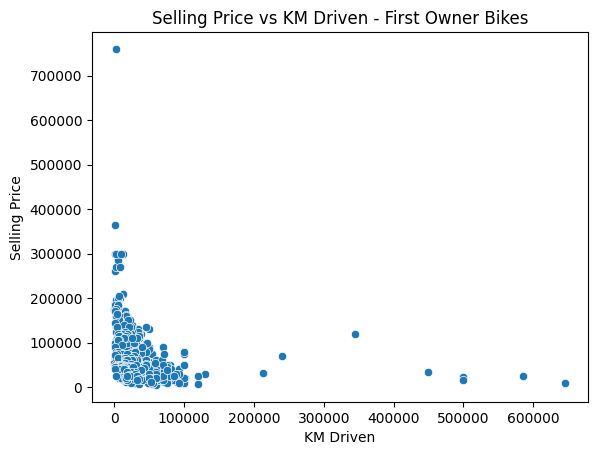

In [52]:
first = bike[bike['owner'].astype(str).str.contains('1st', case=False, na=False)].copy()
print("First-owner rows:", len(first))
print("Correlation:", first['selling_price'].corr(first['km_driven']))

sns.scatterplot(data=first, x='km_driven', y='selling_price')
plt.title('Selling Price vs KM Driven - First Owner Bikes')
plt.xlabel('KM Driven')
plt.ylabel('Selling Price')
plt.show()

## 11. Identify and remove outliers in the km_driven column using the IQR method.

In [53]:
q1 = bike['km_driven'].quantile(0.25)
q3 = bike['km_driven'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = bike[(bike['km_driven'] < lower) | (bike['km_driven'] > upper)]
bike_clean = bike[(bike['km_driven'] >= lower) & (bike['km_driven'] <= upper)].copy()

print("Q1:", q1, "Q3:", q3, "IQR:", iqr)
print("Lower bound:", lower, "Upper bound:", upper)
print("Outliers removed:", len(outliers))
print("New dataset shape:", bike_clean.shape)

Q1: 13500.0 Q3: 43000.0 IQR: 29500.0
Lower bound: -30750.0 Upper bound: 87250.0
Outliers removed: 39
New dataset shape: (1022, 7)


## 12. Perform a bivariate analysis to visualize the relationship between year and selling_price.

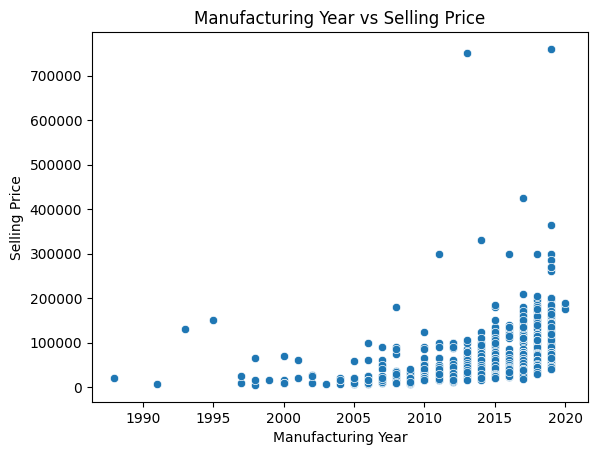

Correlation: 0.40218840061474403


In [54]:
sns.scatterplot(data=bike, x='year', y='selling_price')
plt.title('Manufacturing Year vs Selling Price')
plt.xlabel('Manufacturing Year')
plt.ylabel('Selling Price')
plt.show()

print("Correlation:", bike['year'].corr(bike['selling_price']))

## 13. What is the average depreciation in selling price based on the bike's age (current year - manufacturing year)?

In [55]:
current_year = pd.Timestamp.today().year
bike['age'] = current_year - pd.to_numeric(bike['year'], errors='coerce')
bike['depreciation'] = pd.to_numeric(bike['ex_showroom_price'], errors='coerce') - pd.to_numeric(bike['selling_price'], errors='coerce')

print("Current year used:", current_year)
print("Average depreciation by bike age:")
display(
    bike.dropna(subset=['age','depreciation'])
        .groupby('age')['depreciation']
        .mean()
        .reset_index(name='average_depreciation')
        .head(20)
)
print("\nOverall average depreciation:", bike['depreciation'].mean())


Current year used: 2026
Average depreciation by bike age:


,age,average_depreciation
0,6,-34260.000000
1,7,2954.562500
2,8,13023.194805
3,9,22306.082353
4,10,28328.190476
5,11,28013.275000
6,12,34505.606061
7,13,43086.886792
8,14,37317.648649
9,15,47102.666667



Overall average depreciation: 28513.549520766774


## 14. Which bike names are priced significantly above the average price for their manufacturing year?

In [56]:
year_avg = bike.groupby('year')['selling_price'].transform('mean')
bike['year_avg_price'] = year_avg
above = bike[bike['selling_price'] > 1.20 * bike['year_avg_price']].copy()

print("Bikes priced more than 20% above their manufacturing-year average:")
display(above[['name','year','selling_price','year_avg_price']].sort_values('selling_price', ascending=False).head(30))

Bikes priced more than 20% above their manufacturing-year average:


,name,year,selling_price,year_avg_price
295,Suzuki GSX S750,2019,760000,119689.511628
134,Harley-Davidson Street Bob,2013,750000,51136.986301
289,Kawasaki Ninja 650 [2018-2019],2017,425000,78894.736842
13,Yamaha YZF R3,2019,365000,119689.511628
311,Harley-Davidson Street 750,2014,330000,48668.131868
344,BMW G310GS,2018,300000,87660.374046
897,Kawasaki Ninja 300,2016,300000,58469.018692
860,Kawasaki Ninja 650 [2018-2019],2011,300000,35655.721311
130,Royal Enfield Continental GT 650,2019,299000,119689.511628
315,Royal Enfield Interceptor 650,2019,285000,119689.511628


## 15. Develop a correlation matrix for numeric columns and visualize it using a heatmap.

,selling_price,year,km_driven,ex_showroom_price,age,depreciation,year_avg_price
selling_price,1.000000,0.402188,-0.212937,0.918583,-0.402188,0.345663,0.501140
year,0.402188,1.000000,-0.288675,0.126378,-1.000000,-0.343490,0.802547
km_driven,-0.212937,-0.288675,1.000000,-0.122011,0.288675,0.066531,-0.309402
ex_showroom_price,0.918583,0.126378,-0.122011,1.000000,-0.126378,0.688385,0.146598
age,-0.402188,-1.000000,0.288675,-0.126378,1.000000,0.343490,-0.802547
depreciation,0.345663,-0.343490,0.066531,0.688385,0.343490,1.000000,-0.366556
year_avg_price,0.501140,0.802547,-0.309402,0.146598,-0.802547,-0.366556,1.000000


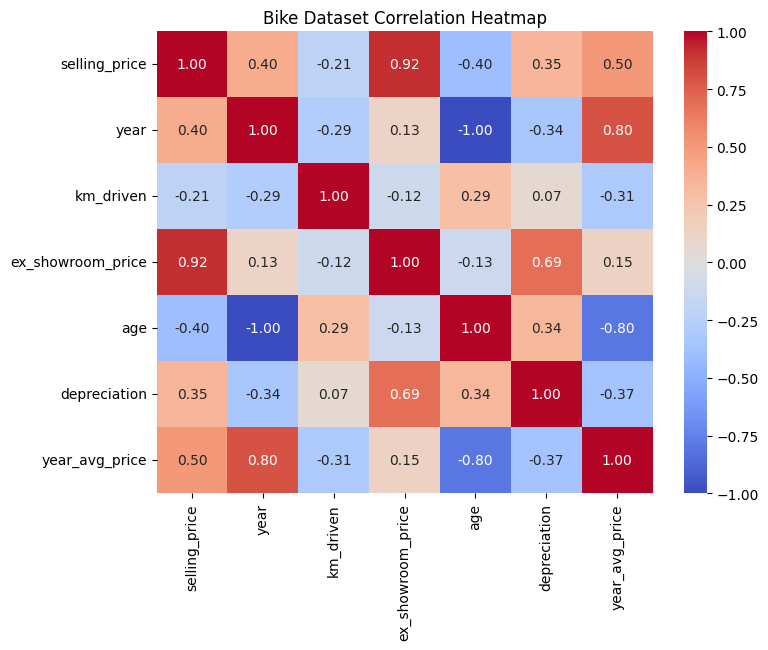

In [57]:
numeric_cols = bike.select_dtypes(include=np.number).columns
corr = bike[numeric_cols].corr()
display(corr)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Bike Dataset Correlation Heatmap')
plt.show()

# EDA - 2

## Car Sale Dataset

The assignment describes a car-sales dataset with columns such as `Car_id`, `Date`, `Customer Name`, `Gender`, `Annual Income`, `Dealer_Name`, `Company`, `Model`, `Engine`, `Transmission`, `Color`, `Price ($)`, `Dealer_No`, `Body Style`, `Phone` and `Dealer_Region`.

In [58]:
car = load_uploaded_file()
scan_data(car, "Car Sales")


Saving Car Sale.csv to Car Sale (1).csv

Car Sales dataset scanned successfully
Shape: (23906, 16)


,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville



Column names:
['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income', 'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color', 'Price ($)', 'Dealer_No', 'Body Style', 'Phone', 'Dealer_Region']

Data types:
Car_id           object
Date             object
Customer Name    object
Gender           object
Annual Income     int64
Dealer_Name      object
Company          object
Model            object
Engine           object
Transmission     object
Color            object
Price ($)         int64
Dealer_No        object
Body Style       object
Phone             int64
Dealer_Region    object
dtype: object

Missing values:
Car_id           0
Date             0
Customer Name    1
Gender           0
Annual Income    0
Dealer_Name      0
Company          0
Model            0
Engine           0
Transmission     0
Color            0
Price ($)        0
Dealer_No        0
Body Style       0
Phone            0
Dealer_Region    0
dtype: int64

Duplicate rows: 0


## 1. What is the average selling price of cars for each dealer, and how does it compare across different dealers?

In [60]:
dealer_avg = car.groupby('Dealer_Name')['Price ($)'].mean().sort_values(ascending=False)
display(dealer_avg.to_frame('Average Price ($)'))

print("Highest average-price dealer:", dealer_avg.index[0])
print("Lowest average-price dealer:", dealer_avg.index[-1])

,Average Price ($)
Dealer_Name,
U-Haul CO,28769.919006
Classic Chevy,28602.014446
Rabun Used Car Sales,28527.536177
Iceberg Rentals,28522.958533
Enterprise Rent A Car,28312.580800
Scrivener Performance Engineering,28297.371589
Gartner Buick Hyundai Saab,28247.621019
Saab-Belle Dodge,28190.139888
Capitol KIA,28189.703822


Highest average-price dealer: U-Haul CO
Lowest average-price dealer: Buddy Storbeck's Diesel Service Inc


## 2. Which car brand (Company) has the highest variation in prices, and what does this tell us about the pricing trends?

In [59]:
variation = car.groupby('Company')['Price ($)'].agg(['std','var','count']).sort_values('std', ascending=False)
display(variation.head(10))
print("Brand with highest price standard deviation:", variation.index[0])

,std,var,count
Company,,,
Lincoln,19658.050211,3.864389e+08,492
Saab,19653.740089,3.862695e+08,210
Cadillac,19517.120220,3.809180e+08,652
Plymouth,19065.997338,3.635123e+08,617
Lexus,17852.923492,3.187269e+08,802
Buick,17142.232626,2.938561e+08,439
Mercury,16445.172195,2.704437e+08,874
Nissan,16214.264017,2.629024e+08,886
Saturn,15990.223671,2.556873e+08,586


Brand with highest price standard deviation: Lincoln


## 3. What is the distribution of car prices for each transmission type, and how do the interquartile ranges compare?

,Q1,Median,Q3,IQR
Transmission,,,,
Auto,19000.0,24000.0,35500.0,16500.0
Manual,17000.0,22001.0,34000.0,17000.0


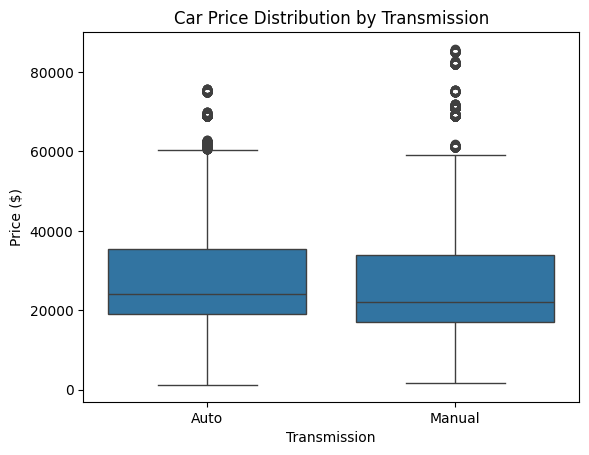

In [61]:
summary = car.groupby('Transmission')['Price ($)'].agg(
    Q1=lambda x: x.quantile(.25),
    Median='median',
    Q3=lambda x: x.quantile(.75),
    IQR=lambda x: x.quantile(.75)-x.quantile(.25)
)
display(summary)

sns.boxplot(data=car, x='Transmission', y='Price ($)')
plt.title('Car Price Distribution by Transmission')
plt.show()

## 4. What is the distribution of car prices across different regions?

,count,mean,50%,min,max
Dealer_Region,,,,,
Aurora,3130.0,28334.626837,23000.0,9000.0,85800.0
Austin,4135.0,28341.603628,23801.0,9000.0,85601.0
Greenville,3128.0,28180.819054,22500.0,1200.0,85200.0
Janesville,3821.0,27833.350955,23000.0,4300.0,85400.0
Middletown,3128.0,27856.338875,22750.0,1700.0,85300.0
Pasco,3131.0,28119.039923,23000.0,9000.0,85600.0
Scottsdale,3433.0,27954.958928,22600.0,1450.0,85001.0


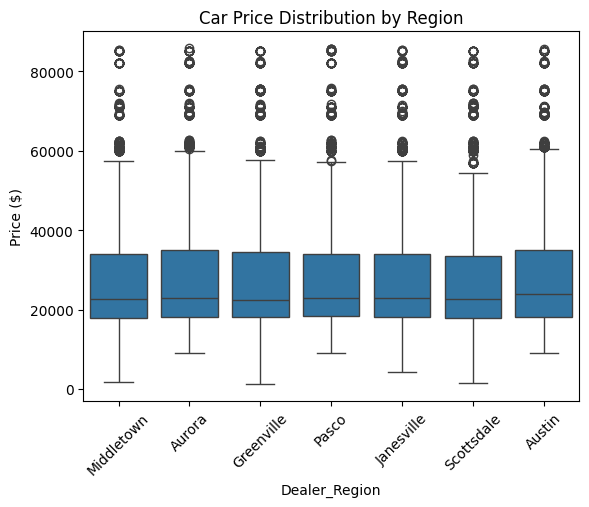

In [62]:
display(car.groupby('Dealer_Region')['Price ($)'].describe()[['count','mean','50%','min','max']])

sns.boxplot(data=car, x='Dealer_Region', y='Price ($)')
plt.xticks(rotation=45)
plt.title('Car Price Distribution by Region')
plt.show()

## 5. What is the distribution of cars based on body styles?

,Count
Body Style,
SUV,6374
Hatchback,6128
Sedan,4488
Passenger,3945
Hardtop,2971


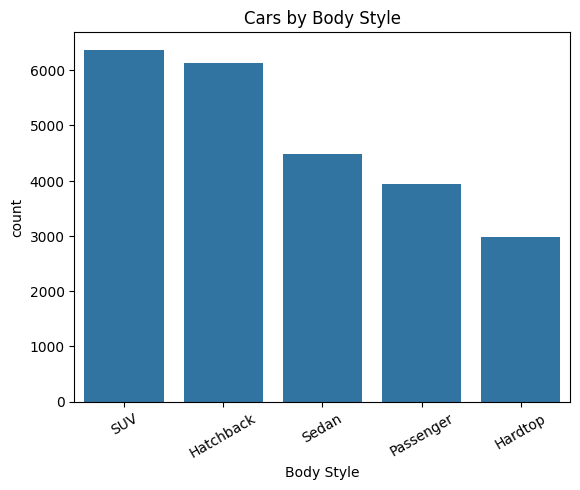

In [63]:
body_counts = car['Body Style'].value_counts()
display(body_counts.to_frame('Count'))

sns.countplot(data=car, x='Body Style', order=body_counts.index)
plt.xticks(rotation=30)
plt.title('Cars by Body Style')
plt.show()

## 6. How does the average selling price of cars vary by customer gender and annual income?

,Gender,income_bracket,Price ($)
0,Female,"(10079.999, 386000.0]",28059.801521
1,Female,"(386000.0, 735000.0]",28353.154717
2,Female,"(735000.0, 1175750.0]",28309.448449
3,Female,"(1175750.0, 11200000.0]",28402.914851
4,Male,"(10079.999, 386000.0]",27924.524014
5,Male,"(386000.0, 735000.0]",27837.224550
6,Male,"(735000.0, 1175750.0]",28283.473409
7,Male,"(1175750.0, 11200000.0]",28091.421784


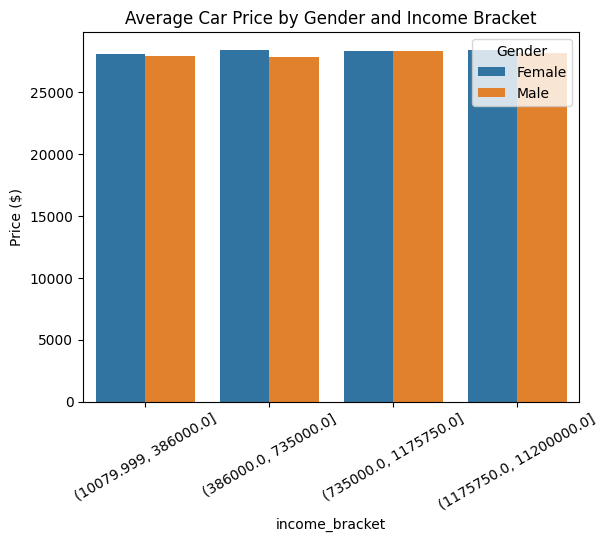

In [64]:
car['income_bracket'] = pd.qcut(car['Annual Income'], q=4, duplicates='drop')
gender_income = car.groupby(['Gender','income_bracket'], observed=False)['Price ($)'].mean().reset_index()
display(gender_income)

sns.barplot(data=gender_income, x='income_bracket', y='Price ($)', hue='Gender')
plt.xticks(rotation=30)
plt.title('Average Car Price by Gender and Income Bracket')
plt.show()

## 7. What is the distribution of car prices by region, and how does the number of cars sold vary by region?

,average_price,cars_sold
Dealer_Region,,
Austin,28341.603628,4135
Janesville,27833.350955,3821
Scottsdale,27954.958928,3433
Pasco,28119.039923,3131
Aurora,28334.626837,3130
Greenville,28180.819054,3128
Middletown,27856.338875,3128


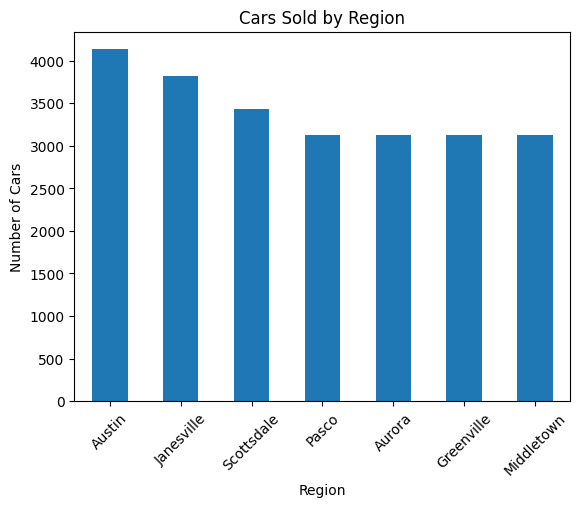

In [65]:
region_summary = car.groupby('Dealer_Region').agg(
    average_price=('Price ($)','mean'),
    cars_sold=('Car_id','count')
).sort_values('cars_sold', ascending=False)
display(region_summary)

fig, ax = plt.subplots()
region_summary['cars_sold'].plot(kind='bar', ax=ax)
ax.set_title('Cars Sold by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Number of Cars')
plt.xticks(rotation=45)
plt.show()

## 8. How does the average car price differ between cars with different engine sizes?

,mean,median,count
Engine,,,
DoubleÂ Overhead Camshaft,28248.525972,24000.0,12571
Overhead Camshaft,27914.710631,22001.0,11335


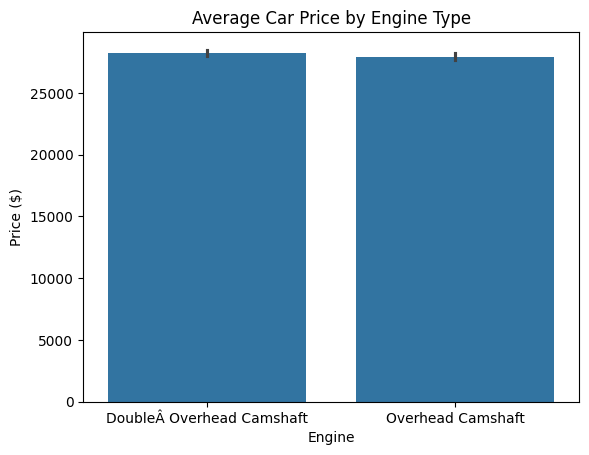

In [66]:
engine_avg = car.groupby('Engine')['Price ($)'].agg(['mean','median','count']).sort_values('mean', ascending=False)
display(engine_avg)

sns.barplot(data=car, x='Engine', y='Price ($)', estimator=np.mean)
plt.title('Average Car Price by Engine Type')
plt.show()

## 9. How do car prices vary based on the customer’s annual income bracket?

,mean,median,count
income_bracket,,,
"(10079.999, 386000.0]",27954.276468,22001.0,5979
"(386000.0, 735000.0]",27974.380371,23000.0,5981
"(735000.0, 1175750.0]",28288.664936,23001.0,5969
"(1175750.0, 11200000.0]",28144.058223,23000.0,5977


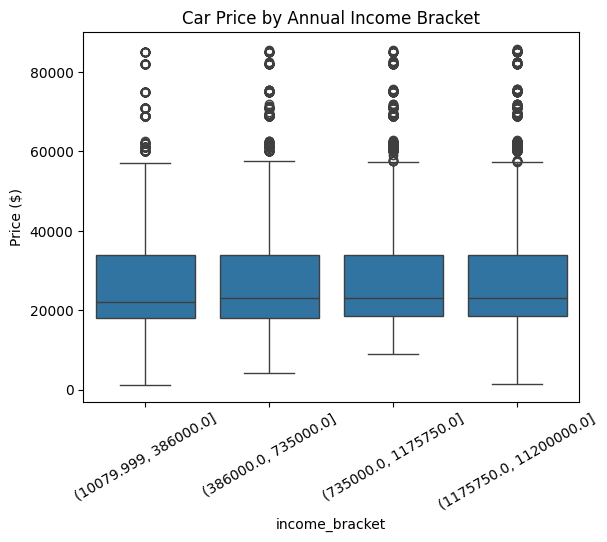

In [67]:
income_price = car.groupby('income_bracket', observed=False)['Price ($)'].agg(['mean','median','count'])
display(income_price)

sns.boxplot(data=car, x='income_bracket', y='Price ($)')
plt.xticks(rotation=30)
plt.title('Car Price by Annual Income Bracket')
plt.show()

## 10. What are the top 5 car models with the highest number of sales, and how does their price distribution look?

Top 5 models:


,Sales
Model,
Diamante,418
Prizm,411
Silhouette,411
Passat,391
Ram Pickup,383


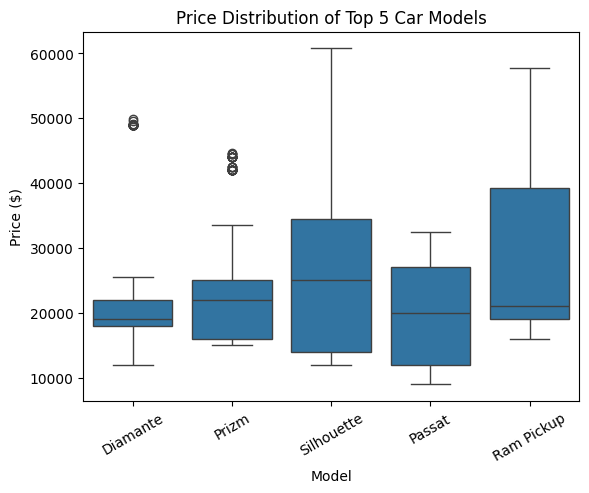

In [68]:
top5_models = car['Model'].value_counts().head(5)
print("Top 5 models:")
display(top5_models.to_frame('Sales'))

top5_data = car[car['Model'].isin(top5_models.index)]
sns.boxplot(data=top5_data, x='Model', y='Price ($)', order=top5_models.index)
plt.xticks(rotation=30)
plt.title('Price Distribution of Top 5 Car Models')
plt.show()

## 11. How does car price vary with engine size across different car colors, and which colors have the highest price variation?

,Color,Engine,Price ($)
0,Black,DoubleÂ Overhead Camshaft,25766.451103
1,Black,Overhead Camshaft,31732.967164
2,Pale White,DoubleÂ Overhead Camshaft,30347.987460
3,Pale White,Overhead Camshaft,24327.767694
4,Red,DoubleÂ Overhead Camshaft,27434.392314
5,Red,Overhead Camshaft,30153.405229


Price variation by color:


,Price Std Dev
Color,
Red,15519.360962
Black,15286.065976
Pale White,14077.346859


Color with highest price variation: Red


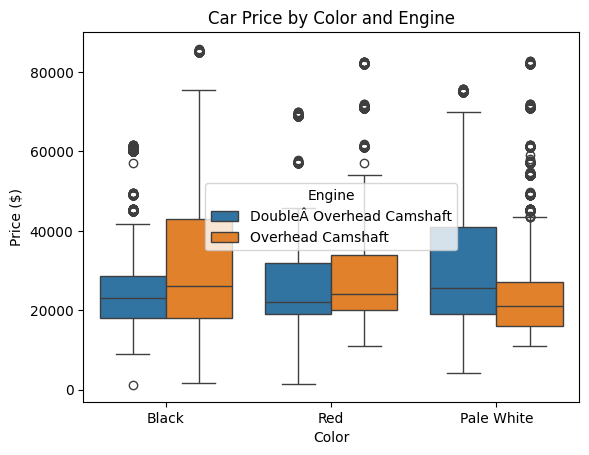

In [69]:
color_engine = car.groupby(['Color','Engine'])['Price ($)'].mean().reset_index()
display(color_engine)

color_variation = car.groupby('Color')['Price ($)'].std().sort_values(ascending=False)
print("Price variation by color:")
display(color_variation.to_frame('Price Std Dev'))
print("Color with highest price variation:", color_variation.index[0])

sns.boxplot(data=car, x='Color', y='Price ($)', hue='Engine')
plt.title('Car Price by Color and Engine')
plt.show()

## 12. Is there any seasonal trend in car sales based on the date of sale?

,month,month_name,sales
0,1,January,790
1,2,February,735
2,3,March,1535
3,4,April,1655
4,5,May,1895
5,6,June,1715
6,7,July,1725
7,8,August,1705
8,9,September,3305
9,10,October,1830


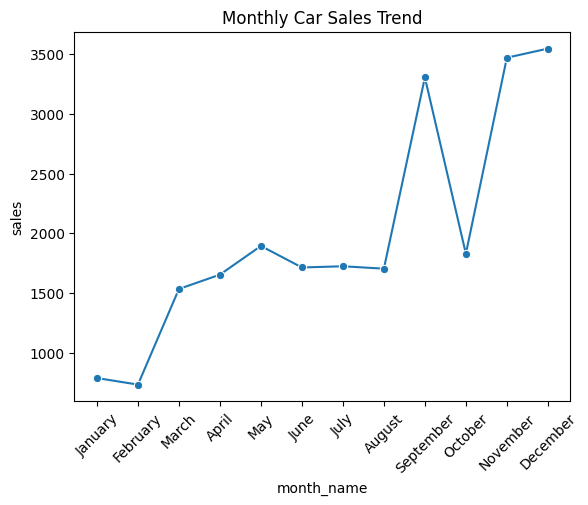

In [70]:
car['Date'] = pd.to_datetime(car['Date'], errors='coerce')
car['month'] = car['Date'].dt.month
car['month_name'] = car['Date'].dt.month_name()

monthly_sales = car.groupby(['month','month_name']).size().reset_index(name='sales').sort_values('month')
display(monthly_sales)

sns.lineplot(data=monthly_sales, x='month_name', y='sales', marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Car Sales Trend')
plt.show()

## 13. How does the car price distribution change when considering different combinations of body style and transmission type?

mean   median  count
Body Style Transmission                              
Hardtop    Auto          31520.188210  27000.0   1408
           Manual        27016.943698  22001.0   1563
Hatchback  Auto          25910.544824  21500.0   3458
           Manual        28702.550562  23000.0   2670
Passenger  Auto          28915.835149  25000.0   2020
           Manual        28969.521039  22000.0   1925
SUV        Auto          27501.404407  25000.0   3086
           Manual        26079.019161  22000.0   3288
Sedan      Auto          29955.294344  26000.0   2599
           Manual        29664.271572  25000.0   1889

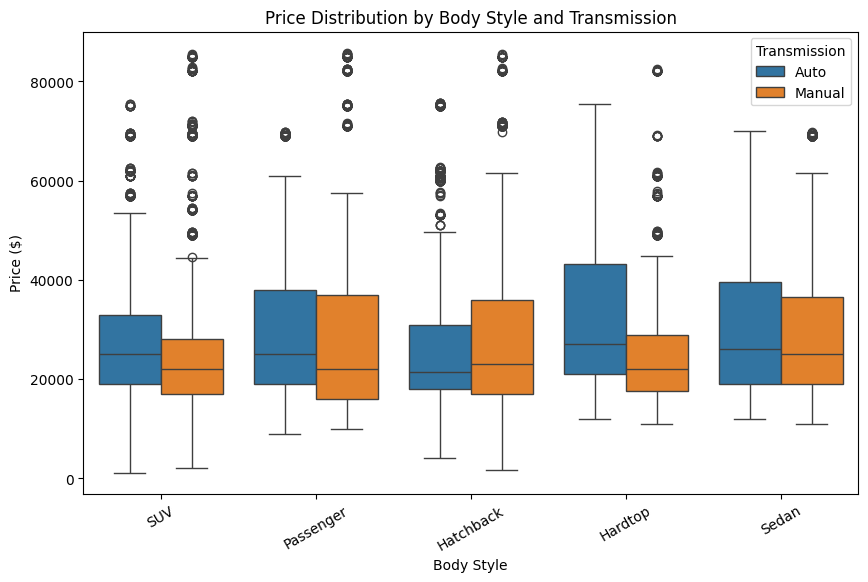

In [71]:
combo = car.groupby(['Body Style','Transmission'])['Price ($)'].agg(['mean','median','count'])
display(combo)

plt.figure(figsize=(10,6))
sns.boxplot(data=car, x='Body Style', y='Price ($)', hue='Transmission')
plt.xticks(rotation=30)
plt.title('Price Distribution by Body Style and Transmission')
plt.show()

## 14. What is the correlation between car price, engine size, and annual income of customers, and how do these features interact?

,Price ($),Annual Income,Engine_code
Price ($),1.000000,0.012065,-0.011271
Annual Income,0.012065,1.000000,-0.006598
Engine_code,-0.011271,-0.006598,1.000000


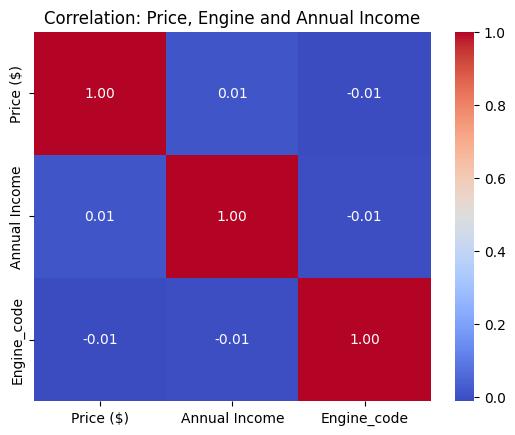

In [72]:
analysis_df = car[['Price ($)','Annual Income']].copy()
analysis_df['Engine_code'] = car['Engine'].astype('category').cat.codes
corr = analysis_df.corr()
display(corr)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation: Price, Engine and Annual Income')
plt.show()

## 15. How does the average car price vary across different car models and engine types?

In [73]:
model_engine = car.groupby(['Model','Engine'])['Price ($)'].mean().reset_index()
display(model_engine.sort_values('Price ($)', ascending=False).head(30))

pivot = car.pivot_table(index='Model', columns='Engine', values='Price ($)', aggfunc='mean')
display(pivot.head(20))

,Model,Engine,Price ($)
212,SC,Overhead Camshaft,61074.818182
198,Ranger,DoubleÂ Overhead Camshaft,61064.055556
222,Sable,Overhead Camshaft,61039.770833
56,Catera,DoubleÂ Overhead Camshaft,56836.933333
143,LX470,Overhead Camshaft,54037.490196
139,LS400,Overhead Camshaft,53157.941558
111,GS400,Overhead Camshaft,53086.000000
239,Tacoma,DoubleÂ Overhead Camshaft,53085.821918
25,Aurora,Overhead Camshaft,51833.556962
173,Park Avenue,DoubleÂ Overhead Camshaft,49387.750000


Engine,DoubleÂ Overhead Camshaft,Overhead Camshaft
Model,,
3-Sep,37986.380117,NaN
3000GT,22764.326923,21770.659864
300M,21394.888889,NaN
323i,16744.632287,21038.162162
328i,21069.149606,38676.177215
4Runner,32167.794118,25075.416667
5-Sep,41067.000000,28071.454545
528i,46288.712963,21197.898148
A4,27070.500000,12046.220000


# EDA - 3

## Amazon Sales Data

The assignment describes an Amazon dataset containing 1K+ products with columns including `product_id`, `product_name`, `category`, `discounted_price`, `actual_price`, `discount_percentage`, `rating`, `rating_count`, review fields and links.

In [74]:
amazon = load_uploaded_file()

# Clean common numeric columns
for col in ['discounted_price','actual_price']:
    if col in amazon.columns:
        amazon[col] = pd.to_numeric(
            amazon[col].astype(str).str.replace(r'[^0-9.]', '', regex=True),
            errors='coerce'
        )

if 'discount_percentage' in amazon.columns:
    amazon['discount_percentage'] = pd.to_numeric(
        amazon['discount_percentage'].astype(str).str.replace('%','', regex=False),
        errors='coerce'
    )

if 'rating' in amazon.columns:
    amazon['rating'] = pd.to_numeric(amazon['rating'], errors='coerce')

if 'rating_count' in amazon.columns:
    amazon['rating_count'] = pd.to_numeric(
        amazon['rating_count'].astype(str).str.replace(',','', regex=False),
        errors='coerce'
    )

scan_data(amazon, "Amazon Sales")


Saving amazon.csv to amazon (1).csv

Amazon Sales dataset scanned successfully
Shape: (1465, 16)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Comp...,Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBC...,399.0,1099.0,64,4.2,24269.0,"High Compatibility : Compatible With iPhone 12, 11, X/XsMax/Xr ,iPhone 8/8 P...","AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBBSNLYT3ONILA,AHCTC6ULH4XB6YHDY6...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jaspreet singh,Khaja moin,Anand,S....","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1KD19VHEDV0OR,R3C02RMYQMK6FC,R39...","Satisfied,Charging is really fast,Value for money,Product review,Good qualit...","Looks durable Charging is fine tooNo complains,Charging is really fast, good...",https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/51UsScvHQNL._SX3...,https://www.amazon.in/Wayona-Braided-WN3LG1-Syncing-Charging/dp/B07JW9H4J1/r...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5m Braided Type C Cable for Sma...,Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBC...,199.0,349.0,43,4.0,43994.0,"Compatible with all Type C enabled devices, be it an android smartphone (Mi,...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBXNGXZJT525AQ,AHONIZU3ICIEHQIGQ6...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Placeholder,BharanI,sonia,Niam","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RYGGS0M09S3KY,R17KQRUTAN5DKS,R3A...","A Good Braided Cable for Your Type C Device,Good quality product from ambran...",I ordered this cable to connect my phone to Android Auto of car. The cable i...,https://m.media-amazon.com/images/W/WEBP_402378-T2/images/I/31zOsqQOAOL._SY4...,https://www.amazon.in/Ambrane-Unbreakable-Charging-Braided-Cable/dp/B098NS6P...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync USB Cable Compatible for iPhone...,Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBC...,199.0,1899.0,90,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safety proctections and four-core c...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQLWQOWZ4N3OA,AHTPQRIMGUD4BYR5YI...","Kunal,Himanshu,viswanath,sai niharka,saqib malik,Aashiq,Ramu Challa,Sanjay g...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R25X4TBMPY91LX,R27OK7G99VK0TR,R2...","Good speed for earlier versions,Good Product,Working good,Good for the price...","Not quite durable and sturdy,https://m.media-amazon.com/images/W/WEBP_402378...",https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/31IvNJZnmdL._SY4...,https://www.amazon.in/Sounce-iPhone-Charging-Compatible-Devices/dp/B096MSW6C...
3,B08HDJ86NZ,"boAt Deuce USB 300 2 in 1 Type-C & Micro USB Stress Resistant, Tangle-Free, ...",Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBC...,329.0,699.0,53,4.2,94363.0,"The boAt Deuce USB 300 2 in 1 cable is compatible with smartphones, tablets,...","AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5SGCUQBP7YSCA,AH725ST5NW2Y4JZPKU...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh chouhan,Ravi Siddan,Himanshu G...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1CLH2ULIVG5U3,R2DMKIBGFKBD6R,RC...","Good product,Good one,Nice,Really nice product,Very first time change,Good,F...","Good product,long wire,Charges good,Nice,I bought this cable for Rs.339 wort...",https://m.media-amazon.com/images/I/41V5FtEWPkL._SX300_SY300_QL70_FMwebp_.jpg,https://www.amazon.in/Deuce-300-Resistant-Tangle-Free-Transmission/dp/B08HDJ...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 Pin USB Cable with Charge & Syn...,Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBC...,154.0,399.0,61,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes with charging & Data sync functio...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZHM4QB2KPKFUQ,AFK4NJOLFSJGWLOJIU...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,


Column names:
['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']

Data types:
product_id              object
product_name            object
category                object
discounted_price       float64
actual_price           float64
discount_percentage      int64
rating                 float64
rating_count           float64
about_product           object
user_id                 object
user_name               object
review_id               object
review_title            object
review_content          object
img_link                object
product_link            object
dtype: object

Missing values:
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 1
rating_count           2
a

## 1. What is the average rating for each product category?

In [76]:
amazon['main_category'] = amazon['category'].astype(str).str.split('|').str[0]
avg_rating = amazon.groupby('main_category')['rating'].mean().sort_values(ascending=False)
display(avg_rating.to_frame('Average Rating'))

,Average Rating
main_category,
OfficeProducts,4.309677
Toys&Games,4.300000
HomeImprovement,4.250000
Computers&Accessories,4.154967
Electronics,4.081749
Home&Kitchen,4.040716
Health&PersonalCare,4.000000
MusicalInstruments,3.900000
Car&Motorbike,3.800000


## 2. What are the top rating_count products by category?

In [77]:
top_by_category = amazon.sort_values('rating_count', ascending=False).groupby('main_category', group_keys=False).head(1)
display(top_by_category[['main_category','product_name','rating_count','rating']].sort_values('rating_count', ascending=False))

,main_category,product_name,rating_count,rating
47,Electronics,"Amazon Basics High-Speed HDMI Cable, 6 Feet - Supports Ethernet, 3D, 4K vide...",426973.0,4.4
1028,Home&Kitchen,Pigeon Polypropylene Mini Handy and Compact Chopper with 3 Blades for Effort...,270563.0,4.1
588,Computers&Accessories,SanDisk Cruzer Blade 32GB USB Flash Drive,253105.0,4.3
613,MusicalInstruments,Boya ByM1 Auxiliary Omnidirectional Lavalier Condenser Microphone with 20ft ...,68664.0,4.0
924,Toys&Games,Faber-Castell Connector Pen Set - Pack of 25 (Assorted),15867.0,4.3
659,OfficeProducts,"Casio FX-82MS 2nd Gen Non-Programmable Scientific Calculator, 240 Functions ...",12179.0,4.4
982,HomeImprovement,"Gizga Essentials Cable Organiser, Cord Management System for PC, TV, Home Th...",5985.0,4.5
1247,Health&PersonalCare,Dr Trust Electronic Kitchen Digital Scale Weighing Machine (Blue),3663.0,4.0
1157,Car&Motorbike,"Reffair AX30 [MAX] Portable Air Purifier for Car, Home & Office | Smart Ioni...",1118.0,3.8


## 3. What is the distribution of discounted prices vs. actual prices?

,discounted_price,actual_price
count,1465.000000,1465.000000
mean,3125.310874,5444.990635
std,6944.304394,10874.826864
min,39.000000,39.000000
25%,325.000000,800.000000
50%,799.000000,1650.000000
75%,1999.000000,4295.000000
max,77990.000000,139900.000000


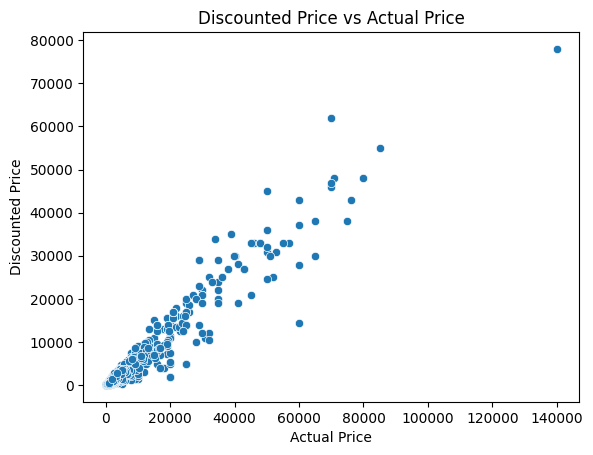

In [78]:
display(amazon[['discounted_price','actual_price']].describe())

sns.scatterplot(data=amazon, x='actual_price', y='discounted_price')
plt.title('Discounted Price vs Actual Price')
plt.xlabel('Actual Price')
plt.ylabel('Discounted Price')
plt.show()

## 4. How does the average discount percentage vary across categories?

,Average Discount %
main_category,
HomeImprovement,57.500000
Computers&Accessories,54.024283
Health&PersonalCare,53.000000
Electronics,50.828897
MusicalInstruments,46.000000
Car&Motorbike,42.000000
Home&Kitchen,40.120536
OfficeProducts,12.354839
Toys&Games,0.000000


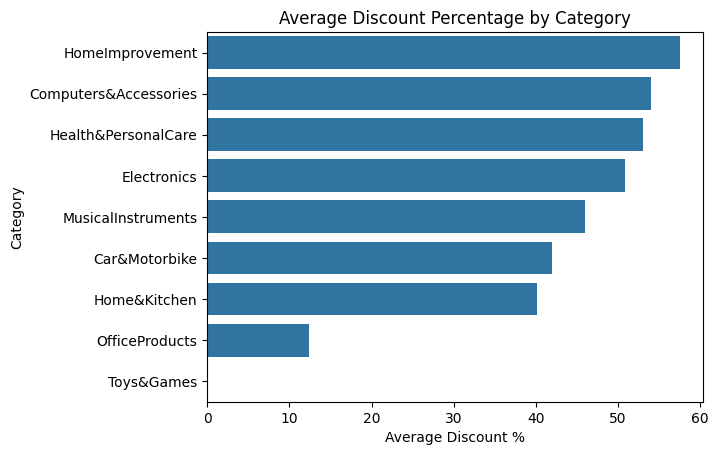

In [79]:
discount_avg = amazon.groupby('main_category')['discount_percentage'].mean().sort_values(ascending=False)
display(discount_avg.to_frame('Average Discount %'))

sns.barplot(x=discount_avg.values, y=discount_avg.index)
plt.title('Average Discount Percentage by Category')
plt.xlabel('Average Discount %')
plt.ylabel('Category')
plt.show()

## 5. What are the most popular product names?

In [80]:
print("Most frequently appearing product names:")
display(amazon['product_name'].value_counts().head(15).to_frame('Count'))

Most frequently appearing product names:


,Count
product_name,
"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Watch with Bluetooth Calling, AI Voice Assistance, 100 Sports Modes IP67 Rating, 240*280 Pixel High Resolution",5
"Fire-Boltt Phoenix Smart Watch with Bluetooth Calling 1.3"",120+ Sports Modes, 240*240 PX High Res with SpO2, Heart Rate Monitoring & IP67 Rating",4
"Amazonbasics Nylon Braided Usb-C To Lightning Cable, Fast Charging Mfi Certified Smartphone, Iphone Charger (6-Foot, Dark Grey)",3
"Duracell USB Lightning Apple Certified (Mfi) Braided Sync & Charge Cable For Iphone, Ipad And Ipod. Fast Charging Lightning Cable, 3.9 Feet (1.2M) - Black",3
Flix Micro Usb Cable For Smartphone (Black),3
"Fire-Boltt India's No 1 Smartwatch Brand Talk 2 Bluetooth Calling Smartwatch with Dual Button, Hands On Voice Assistance, 60 Sports Modes, in Built Mic & Speaker with IP68 Rating",3
"Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Compatible for iPhone 13, 12,11, X, 8, 7, 6, 5, iPad Air, Pro, Mini (3 FT Pack of 1, Grey)",3
"Ambrane Unbreakable 60W / 3A Fast Charging 1.5m Braided Type C Cable for Smartphones, Tablets, Laptops & other Type C devices, PD Technology, 480Mbps Data Sync, Quick Charge 3.0 (RCT15A, Black)",3
"Sounce Fast Phone Charging Cable & Data Sync USB Cable Compatible for iPhone 13, 12,11, X, 8, 7, 6, 5, iPad Air, Pro, Mini & iOS Devices",3


## 6. What are the most popular product keywords?

In [81]:
text = amazon['product_name'].fillna('').astype(str).str.lower()
words = text.str.findall(r'\b[a-zA-Z][a-zA-Z0-9-]{2,}\b').explode()
stop = {'the','and','for','with','from','this','that','pack','inch','black','new','best'}
keywords = words[~words.isin(stop)].value_counts().head(20)
display(keywords.to_frame('Keyword Count'))

,Keyword Count
product_name,
cable,414
usb,391
charging,247
fast,211
smart,175
white,169
type,151
compatible,146
data,136


## 7. What are the most popular product reviews?

In [82]:
print("Most common review titles:")
display(amazon['review_title'].fillna('').value_counts().head(15).to_frame('Count'))

print("Most common review contents (first 10):")
display(amazon['review_content'].fillna('').value_counts().head(10).to_frame('Count'))

Most common review titles:


,Count
review_title,
"Worked on iPhone 7 and didn’t work on XR,Good one,Dull Physical Looks,Just Buy it,Go for it,About the product,Get charging cable at the price,Working well.",10
"Satisfied,Charging is really fast,Value for money,Product review,Good quality,Good product,Good Product,As of now seems good",8
"Phone, camera, heating - works for me, may not for all,Good Mobile,Good but not excellent under this budget,Worth the price at 9499,Ok type phone... but unable to make videocall within same service provider.,Phone review,Budget king,Battery backup is good",8
"A Good Braided Cable for Your Type C Device,Good quality product from ambrane,Super cable,As,Good quality,Good product,its good,Good quality for the price but one issue with my unit",7
"Good product,Good one,Nice,Really nice product,Very first time change,Good,Fine product but could be better,Very nice it's charging like jet",7
"Above average phone,Worth For The Money 💰,Okie,Phone is excellent,Purchased in good budget at 12k,It can fulfill basic needs in affordable price range,Nice,About features",6
"Fake Product,Costly but excellent quality,Storage good but don't know how to Activate warantee??,Good for use,5 stas nahi diya kyuki capacity 477gb hi rahta hai,Speed not as advertise,Good one,It's ok",6
"The metal pin is losing it's strength,Sahi h bs 44 rupe ki and dilivery charge 40,Good Charging cable,Good sturdy micro usb cable with good charging speeds,Cheapest micro USB cable in the market,boat is better than this,I bought this for 199rs best charging cable for all mobiles,Good",5
"GOOD,Thank you Amazon very good charging cable,Good,Very good product,good quality,Very Good Product,This is fast charging USB!,Simply perfect at the price of below 100",5


Most common review contents (first 10):


Count
review_content                                                                         
I am not big on camera usage, personally. I was even mentally prepared for a ...      8
Good product,long wire,Charges good,Nice,I bought this cable for Rs.339 worth...      7
I ordered this cable to connect my phone to Android Auto of car. The cable is...      7
Worked on iPhone 7 and didn’t work on iPhone XR,https://m.media-amazon.com/im...      7
I purchased the 6/128gb variant.To sum  it up in to pros and cons.Pros :-1.Go...      6
128GB SD Card is showing 134GBDon't buy this product,It was a bit costly but ...      6
Everything is fine but it is bulky and hard, it should be softer and thinner....      5
Good budget mfi certified lightly cable for this price . Update usage review ...      5
About the TV - Wonderful-----------------------------------------------------...      5
I liked it, worth the money, light weight and comfortable at every situation....      5

## 8. What is the correlation between discounted_price and rating?

,discounted_price,rating
discounted_price,1.000000,0.120337
rating,0.120337,1.000000


Correlation: 0.12033741712288648


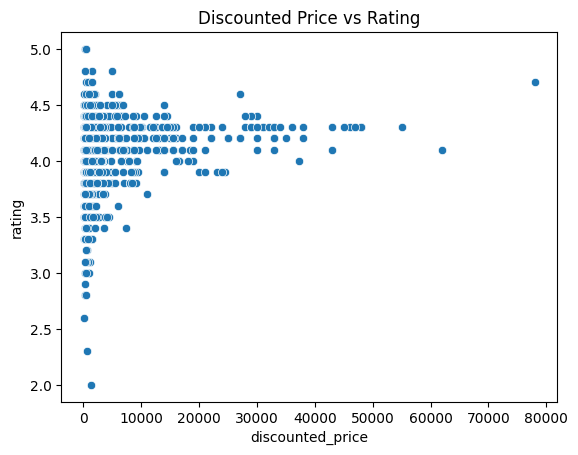

In [83]:
corr = amazon[['discounted_price','rating']].corr()
display(corr)
print("Correlation:", corr.loc['discounted_price','rating'])

sns.scatterplot(data=amazon, x='discounted_price', y='rating')
plt.title('Discounted Price vs Rating')
plt.show()

## 9. What are the Top 5 categories based on the highest ratings?

In [84]:
top_categories = amazon.groupby('main_category')['rating'].mean().sort_values(ascending=False).head(5)
display(top_categories.to_frame('Average Rating'))

,Average Rating
main_category,
OfficeProducts,4.309677
Toys&Games,4.300000
HomeImprovement,4.250000
Computers&Accessories,4.154967
Electronics,4.081749


## 10. Identify any potential areas for improvement or optimization based on the data analysis.

In [85]:
print("Possible improvement areas based on the dataset:")
print("1. Check categories with low average ratings and high rating counts.")
print("2. Compare very high discounts with product ratings to identify weak value products.")
print("3. Improve product titles/keywords for products with low visibility or repeated names.")
print("4. Investigate products with many reviews but relatively low ratings.")
print("5. Review missing values in important numeric columns before further analysis.")

low_rating = amazon.groupby('main_category').agg(
    avg_rating=('rating','mean'),
    avg_discount=('discount_percentage','mean'),
    total_reviews=('rating_count','sum')
).sort_values('avg_rating')
display(low_rating.head(10))

Possible improvement areas based on the dataset:
1. Check categories with low average ratings and high rating counts.
2. Compare very high discounts with product ratings to identify weak value products.
3. Improve product titles/keywords for products with low visibility or repeated names.
4. Investigate products with many reviews but relatively low ratings.
5. Review missing values in important numeric columns before further analysis.


,avg_rating,avg_discount,total_reviews
main_category,,,
Car&Motorbike,3.800000,42.000000,1118.0
MusicalInstruments,3.900000,46.000000,88882.0
Health&PersonalCare,4.000000,53.000000,3663.0
Home&Kitchen,4.040716,40.120536,2991069.0
Electronics,4.081749,50.828897,15778848.0
Computers&Accessories,4.154967,54.024283,7728689.0
HomeImprovement,4.250000,57.500000,8566.0
Toys&Games,4.300000,0.000000,15867.0
OfficeProducts,4.309677,12.354839,149675.0


# EDA - 4

## Spotify Data: Popular Hip-Hop Artists and Tracks

The assignment describes approximately 500 hip-hop tracks with columns `Artist`, `Track Name`, `Popularity`, `Duration (ms)` and `Track ID`.

In [86]:
spotify = load_uploaded_file()

for col in ['Popularity','Duration (ms)']:
    if col in spotify.columns:
        spotify[col] = pd.to_numeric(spotify[col], errors='coerce')

scan_data(spotify, "Spotify Hip-Hop")

# Do the needed cleanup
spotify = spotify.drop_duplicates().copy()
for col in ['Popularity','Duration (ms)']:
    spotify[col] = spotify[col].fillna(spotify[col].median())
spotify['Artist'] = spotify['Artist'].fillna('Unknown')
spotify['Track Name'] = spotify['Track Name'].fillna('Unknown')

print("\nAfter cleaning:")
print("Shape:", spotify.shape)
print("Total null values:", spotify.isnull().sum().sum())


Saving spotify.csv to spotify (1).csv

Spotify Hip-Hop dataset scanned successfully
Shape: (440, 5)


,Artist,Track Name,Popularity,Duration (ms),Track ID
0,Drake,Rich Baby Daddy (feat. Sexyy Red & SZA),92,319191,1yeB8MUNeLo9Ek1UEpsyz6
1,Drake,One Dance,91,173986,1zi7xx7UVEFkmKfv06H8x0
2,Drake,IDGAF (feat. Yeat),90,260111,2YSzYUF3jWqb9YP9VXmpjE
3,Drake,First Person Shooter (feat. J. Cole),88,247444,7aqfrAY2p9BUSiupwk3svU
4,Drake,Jimmy Cooks (feat. 21 Savage),88,218364,3F5CgOj3wFlRv51JsHbxhe



Column names:
['Artist', 'Track Name', 'Popularity', 'Duration (ms)', 'Track ID']

Data types:
Artist           object
Track Name       object
Popularity        int64
Duration (ms)     int64
Track ID         object
dtype: object

Missing values:
Artist           0
Track Name       0
Popularity       0
Duration (ms)    0
Track ID         0
dtype: int64

Duplicate rows: 27

After cleaning:
Shape: (413, 5)
Total null values: 0


## 1. Read the dataframe, check null value if present then do the needful, check duplicate row, if present then do the needful.

In [87]:
print("Rows and columns:", spotify.shape)
print("Null values after cleaning:")
print(spotify.isnull().sum())
print("Duplicate rows after cleaning:", spotify.duplicated().sum())

Rows and columns: (413, 5)
Null values after cleaning:
Artist           0
Track Name       0
Popularity       0
Duration (ms)    0
Track ID         0
dtype: int64
Duplicate rows after cleaning: 0


## 2. What is the distribution of popularity among the tracks in the dataset? Visualize it using a histogram.

count    413.000000
mean      75.384988
std        9.789010
min       29.000000
25%       70.000000
50%       76.000000
75%       82.000000
max       97.000000
Name: Popularity, dtype: float64


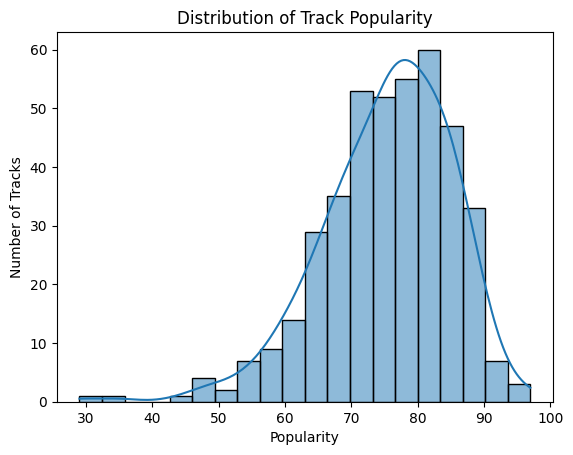

In [88]:
print(spotify['Popularity'].describe())

sns.histplot(spotify['Popularity'], bins=20, kde=True)
plt.title('Distribution of Track Popularity')
plt.xlabel('Popularity')
plt.ylabel('Number of Tracks')
plt.show()

## 3. Is there any relationship between the popularity and the duration of tracks? Explore this using a scatter plot.

Correlation: 0.03899200928439096


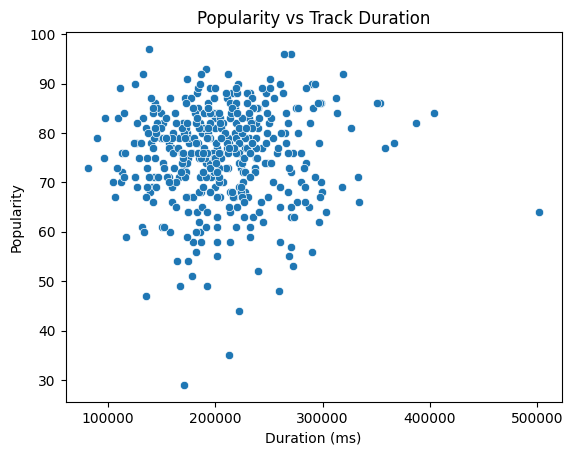

In [89]:
print("Correlation:", spotify['Popularity'].corr(spotify['Duration (ms)']))

sns.scatterplot(data=spotify, x='Duration (ms)', y='Popularity')
plt.title('Popularity vs Track Duration')
plt.xlabel('Duration (ms)')
plt.ylabel('Popularity')
plt.show()

## 4. Which artist has the highest number of tracks in the dataset? Display the count of tracks for each artist using a countplot.

Artist with highest number of tracks: Drake
Number of tracks: 17


,Track Count
Artist,
Drake,17
Eminem,11
Lil Nas X,10
JAY-Z,10
21 Savage,10
Flo Rida,10
¥$,10
Timbaland,10
Ludacris,10


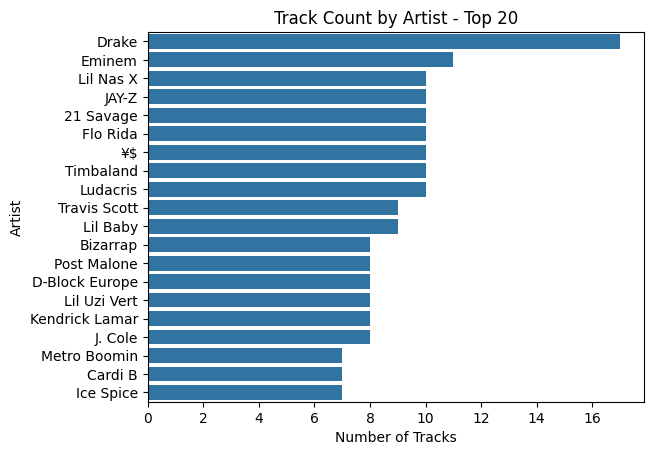

In [90]:
artist_counts = spotify['Artist'].value_counts()
print("Artist with highest number of tracks:", artist_counts.index[0])
print("Number of tracks:", artist_counts.iloc[0])

display(artist_counts.head(20).to_frame('Track Count'))

top_artists_for_plot = artist_counts.head(20)
sns.barplot(x=top_artists_for_plot.values, y=top_artists_for_plot.index)
plt.title('Track Count by Artist - Top 20')
plt.xlabel('Number of Tracks')
plt.ylabel('Artist')
plt.show()

## 5. What are the top 5 least popular tracks in the dataset? Provide the artist name and track name for each.

In [91]:
least5 = spotify.nsmallest(5, 'Popularity')
display(least5[['Artist','Track Name','Popularity']])

,Artist,Track Name,Popularity
207,Pressa,Attachments (feat. Coi Leray),29
231,Justin Bieber,Intentions,35
413,French Montana,Splash Brothers,44
225,Lil Baby,On Me - Remix,47
407,Wyclef Jean,911 (feat. Mary J. Blige),48


## 6. Among the top 5 most popular artists, which artist has the highest popularity on average? Calculate and display the average popularity for each artist.

In [92]:
artist_summary = spotify.groupby('Artist').agg(
    track_count=('Track ID','count'),
    avg_popularity=('Popularity','mean')
).sort_values('track_count', ascending=False)

top5_artists = artist_summary.head(5).copy()
display(top5_artists)

best_artist = top5_artists['avg_popularity'].idxmax()
print("Highest average popularity among these top 5 artists:", best_artist)
print("Average popularity:", top5_artists.loc[best_artist,'avg_popularity'])

,track_count,avg_popularity
Artist,,
Drake,17,82.882353
Eminem,11,83.636364
21 Savage,10,83.800000
Flo Rida,10,78.000000
JAY-Z,10,77.900000


Highest average popularity among these top 5 artists: 21 Savage
Average popularity: 83.8


## 7. For the top 5 most popular artists, what are their most popular tracks? List the track name for each artist.

In [93]:
top5_names = artist_summary.head(5).index
top_tracks = spotify[spotify['Artist'].isin(top5_names)].sort_values(
    ['Artist','Popularity'], ascending=[True,False]
).groupby('Artist', as_index=False).head(1)

display(top_tracks[['Artist','Track Name','Popularity']].sort_values('Popularity', ascending=False))

,Artist,Track Name,Popularity
70,21 Savage,redrum,96
0,Drake,Rich Baby Daddy (feat. Sexyy Red & SZA),92
80,Eminem,Without Me,90
100,JAY-Z,Ni**as In Paris,86
300,Flo Rida,Low (feat. T-Pain),84


## 8. Visualize relationships between multiple numerical variables simultaneously using a pair plot.

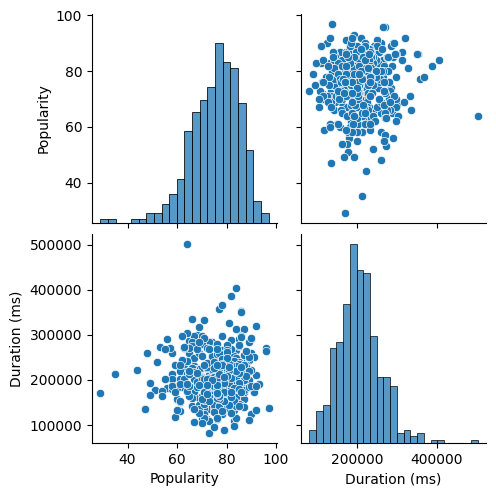

In [94]:
pair_data = spotify[['Popularity','Duration (ms)']].dropna().copy()
sns.pairplot(pair_data)
plt.show()


## 9. Does the duration of tracks vary significantly across different artists? Explore this visually using a box plot or violin plot.

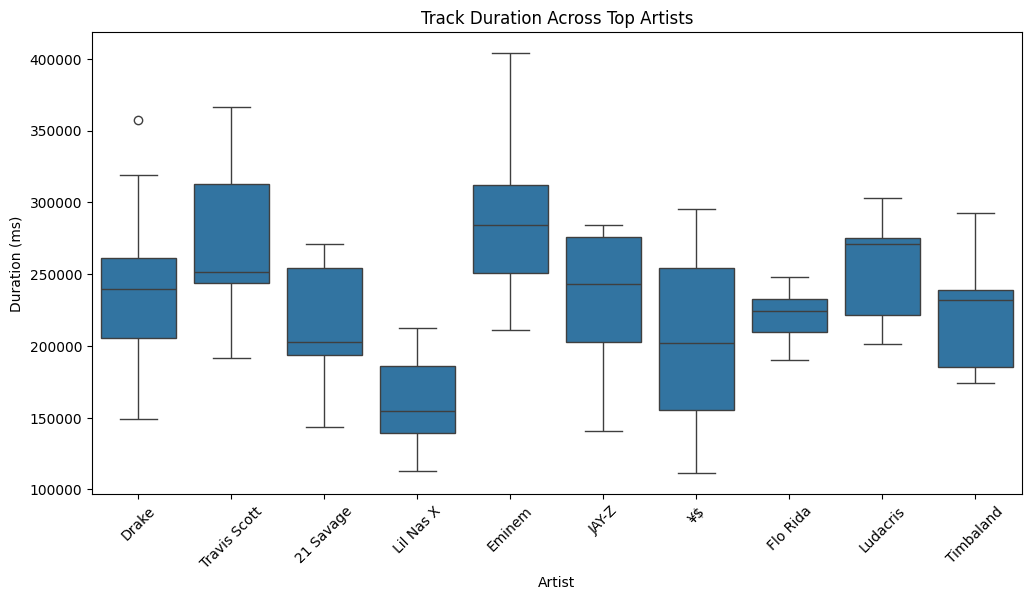

,mean,median,std
Artist,,,
¥$,202406.600000,202347.0,65018.834133
Travis Scott,270723.111111,251249.0,60670.663882
Eminem,285642.181818,284200.0,58133.599333
Drake,241581.529412,239359.0,53991.410875
JAY-Z,232998.300000,243426.5,50856.398575
21 Savage,215707.100000,202938.5,41243.843022
Timbaland,220084.600000,232213.0,37932.559334
Ludacris,255682.200000,270806.0,36004.823667
Lil Nas X,159372.400000,154381.5,35940.037406


In [95]:
top10 = spotify['Artist'].value_counts().head(10).index
duration_data = spotify[spotify['Artist'].isin(top10)]

plt.figure(figsize=(12,6))
sns.boxplot(data=duration_data, x='Artist', y='Duration (ms)')
plt.xticks(rotation=45)
plt.title('Track Duration Across Top Artists')
plt.show()

display(duration_data.groupby('Artist')['Duration (ms)'].agg(['mean','median','std']).sort_values('std', ascending=False))

## 10. How does the distribution of track popularity vary for different artists? Visualize this using a swarm plot or a violin plot.

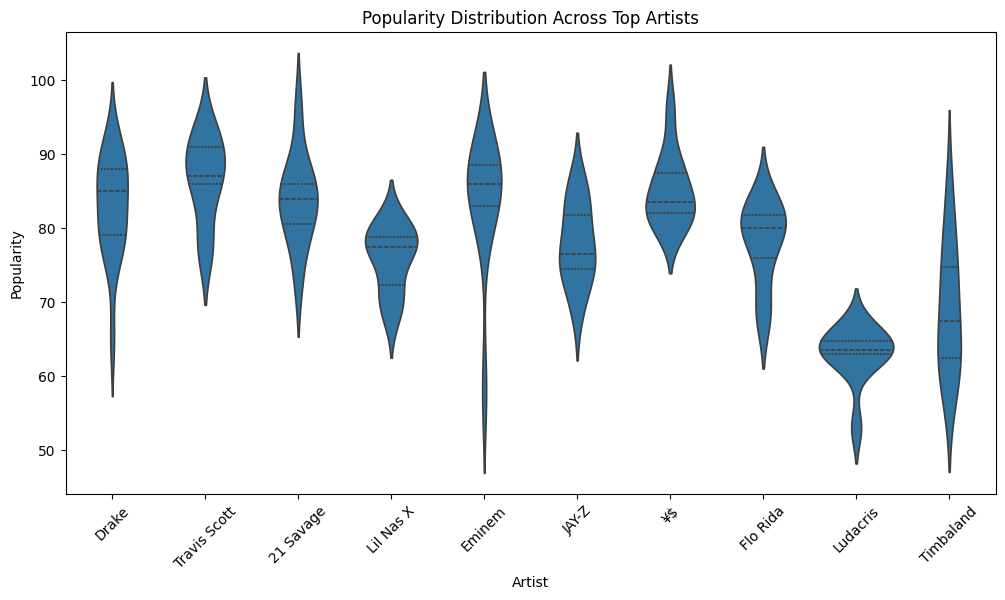

In [96]:
top10 = spotify['Artist'].value_counts().head(10).index
pop_data = spotify[spotify['Artist'].isin(top10)]

plt.figure(figsize=(12,6))
sns.violinplot(data=pop_data, x='Artist', y='Popularity', inner='quartile')
plt.xticks(rotation=45)
plt.title('Popularity Distribution Across Top Artists')
plt.show()